<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/04.4_Building_Models_with_Distance_Metrics_and_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 4 - Membangun Model dengan Metrik Jarak dan Tetangga Terdekat (Building Models with Distance Metrics and Nearest Neighbors)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 4 Building Models with Distance Metrics and Nearest Neighbors** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Memuat perpustakaan
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Muat kumpulan data iris
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

### Bagaimana cara melakukannya
Untuk mengimplementasikan model KNN dasar menggunakan scikit-learn, ikuti langkah-langkah berikut. Seperti yang Anda lihat, model ini mengikuti paradigma desain yang sama dengan model lain yang telah kita lihat dalam buku ini sejauh ini.

In [2]:
# Memuat perpustakaan
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Membuat dan melatih model KNN dasar
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Buatlah prediksi
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


### Cara kerjanya
Algoritma KNN bekerja dengan:
1. Menyimpan semua contoh pelatihan
2. Untuk setiap poin baru:
   - Menghitung jarak ke semua contoh pelatihan
   - Menemukan k k-Nearest Neighbors (k-NN)
   - Mengambil suara terbanyak (untuk klasifikasi) atau rata-rata (untuk regresi)

## Ikhtisar Metrik Jarak

### Bersiap
Kami akan membuat dua kumpulan data baru untuk mengilustrasikan perbedaan antara metrik jarak menggunakan fungsi make_circles() bawaan scikit-learn.

In [3]:
# Memuat perpustakaan
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Buat dua kumpulan data sintetis yang menyoroti perbedaan metrik
n_samples = 300

# Kumpulan data melingkar dengan noise tinggi (jarak Euclidean seharusnya bekerja lebih baik)
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

# Kumpulan data pola kotak-kotak (jarak Manhattan seharusnya bekerja lebih baik)
x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024
)

### Bagaimana cara melakukannya

Untuk membandingkan berbagai metrik jarak, kami akan menelusuri masing-masing metrik dan membuat dua Classifier KNN pada kumpulan data kami, lalu memvisualisasikan kumpulan data tersebut bersama dengan metrik kinerja, akurasi.

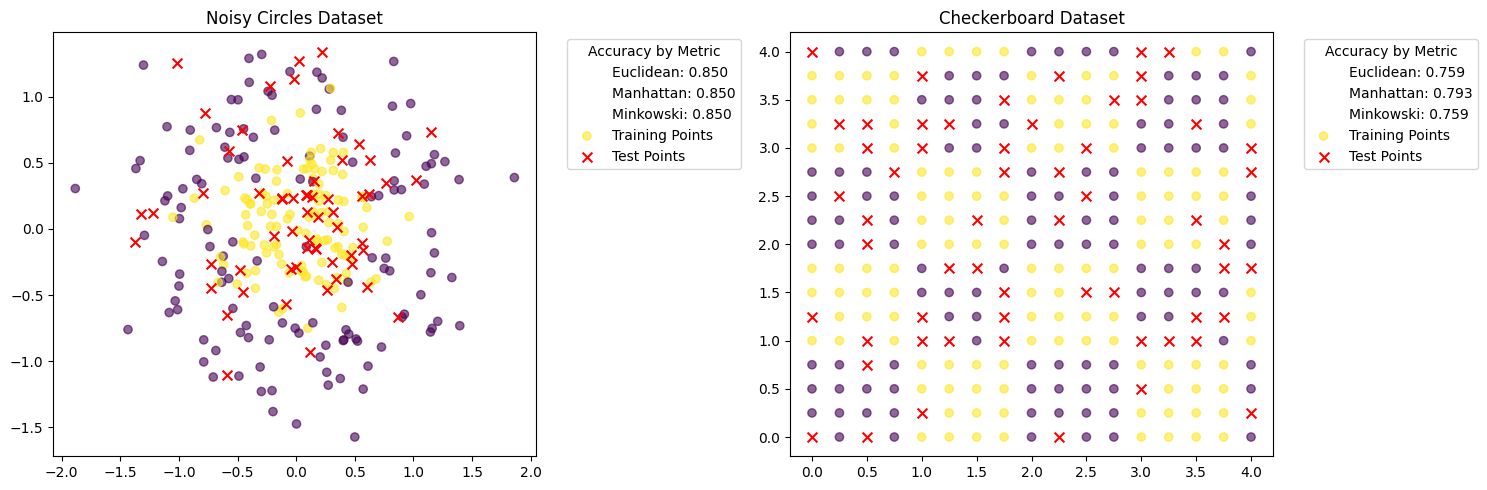

In [4]:
# Bandingkan metrik jarak yang berbeda pada kedua kumpulan data
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    # Uji pada kumpulan data "lingkaran".
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)
    
    # Uji pada kumpulan data "bulan".
    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

# Siapkan spesifikasi plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Kumpulan data lingkaran plot
scatter1_train = ax1.scatter(X_circles_train[:, 0], X_circles_train[:, 1], c=y_circles_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter1_test = ax1.scatter(X_circles_test[:, 0], X_circles_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax1.set_title('Noisy Circles Dataset')

# Buat garis tiruan untuk legenda
lines1 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text1 = [
    f"Euclidean: {results['circles']['euclidean']:.3f}",
    f"Manhattan: {results['circles']['manhattan']:.3f}",
    f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(lines1 + [scatter1_train, scatter1_test], legend_text1 + ['Training Points', 'Test Points'], 
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot kumpulan data bulan
scatter2_train = ax2.scatter(X_moons_train[:, 0], X_moons_train[:, 1], c=y_moons_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter2_test = ax2.scatter(X_moons_test[:, 0], X_moons_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax2.set_title('Checkerboard Dataset')

# Buat garis tiruan untuk legenda
lines2 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text2 = [
    f"Euclidean: {results['moons']['euclidean']:.3f}",
    f"Manhattan: {results['moons']['manhattan']:.3f}",
    f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(lines2 + [scatter2_train, scatter2_test], legend_text2 + ['Training Points', 'Test Points'],
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Penyetelan Hyperparameter di KNN

Penyetelan hyperparameter adalah langkah penting dalam mengoptimalkan performa model pembelajaran mesin, termasuk KNN

### Bersiap

Kami akan menggunakan kumpulan data asli kami, kumpulan data Iris, dan menyesuaikan jumlah tetangga, apakah akan memberi bobot pada data latih kami berdasarkan jarak dari data uji kami atau tidak, dan pilihan metrik jarak.

### Bagaimana cara melakukannya

Untuk melakukan penyetelan hyperparameter untuk KNN, kita akan menggunakan pendekatan Grid Search. Grid Search adalah teknik hyperparameter yang menguji sejumlah besar kombinasi hyperparameter model – semua kombinasi diuji dan kombinasi yang dihasilkan dikembalikan kepada kami sebagai himpunan optimal. Selain itu, Cross-Validation digunakan untuk menambahkan elemen pengacakan yang membantu memastikan model kami kuat saat digunakan di dunia nyata.

In [5]:
# Memuat perpustakaan
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Buat Classifier KNN
knn = KNeighborsClassifier()

# Tentukan kisi parameter
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan']
}

# Buat pencarian jaringan
grid_search = GridSearchCV(
    knn, param_grid, cv=5, scoring='accuracy'
)

# Cocokkan pencarian jaringan
grid_search.fit(X_train, y_train)

# Cetak parameter dan skor terbaik
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668


## Mengevaluasi Kinerja KNN

Mengevaluasi performa model KNN sangat penting untuk memahami seberapa baik model tersebut membuat prediksi dan bagian mana yang mungkin memerlukan perbaikan. Bagian ini akan mencakup berbagai teknik untuk menilai kinerja KNN, termasuk matriks konfusi, presisi, perolehan, dan skor F1. 

### Bersiap
Sekali lagi, kita akan menggunakan kumpulan data mainan sebelumnya, kumpulan data Iris, dan mengimpor beberapa fungsi baru untuk membantu mengevaluasi model kita. Kami akan mengevaluasi model kami menggunakan:
- Skor Cross-Validation
- Kurva belajar
- Confusion Matrix

In [6]:
# Memuat perpustakaan
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

### Bagaimana cara melakukannya...

Untuk mengevaluasi performa model KNN Anda, kami akan menggunakan tiga pendekatan berbeda yang disebutkan di atas. Jika Anda merujuk pada visualisasi yang terletak di output blok kode ini, Anda akan mendapatkan beberapa wawasan tentang performa model Anda. Misalnya, Learning Curve menunjukkan bahwa model tidak mengalami banyak kemajuan setelah ~50 contoh pelatihan, dan matriks konfusi menunjukkan bahwa model mengalami kesulitan dalam membedakan antara kelas pertama dan kedua.

Laporan klasifikasi memberikan perincian mendetail tentang performa model, termasuk presisi, perolehan, dan skor F1 untuk setiap kelas. Fakta bahwa kelas setosa memiliki presisi, perolehan, dan skor F1 yang tinggi menunjukkan bahwa model tersebut berfungsi dengan baik dalam memprediksi kelas ini, namun karena model tersebut memprediksi dengan akurasi 100 persen, hal ini mungkin merupakan indikasi Overfitting.

(CATATAN: Ukuran "akurasi" ditampilkan dalam tabel tiga kali, namun nilainya sama untuk setiap kelas karena akurasi adalah ukuran keseluruhan performa model di seluruh kelas.)

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9916666666666668
Standard deviation: 0.016666666666666653


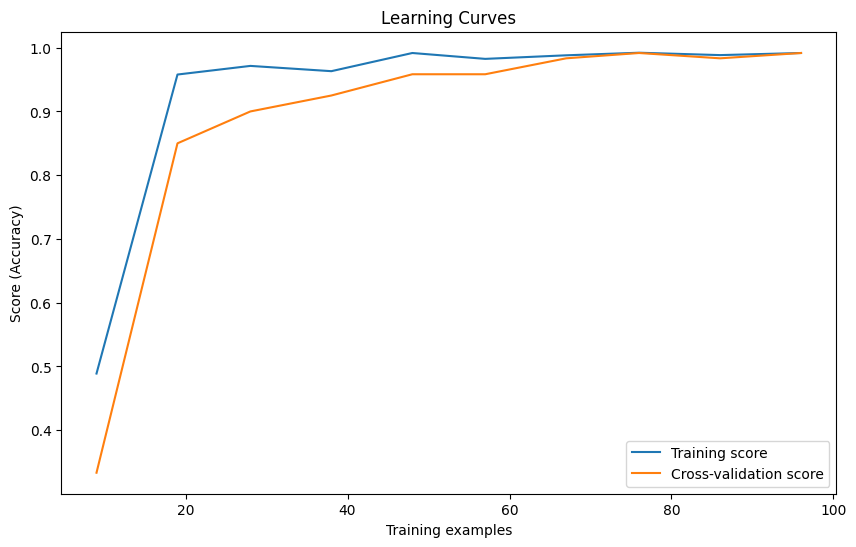

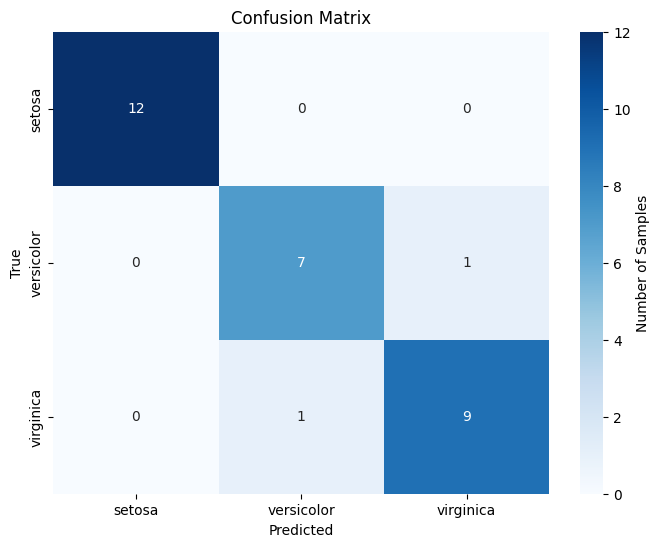


Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


In [7]:
# Dapatkan skor Cross-Validation
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

# Hasilkan Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5
)

# Learning Curve plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score (Accuracy)')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.show()

# Buat prediksi pada set tes
y_pred = grid_search.best_estimator_.predict(X_test)

# Dapatkan nama kelas dari kumpulan data iris
class_names = iris.target_names

# Hasilkan dan plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Dapatkan laporan klasifikasi sebagai dict
report_dict = classification_report(y_test, y_pred, 
                                  target_names=class_names,
                                  output_dict=True)

# Buat DataFrame untuk visualisasi yang lebih baik
report_df = pd.DataFrame(report_dict).transpose()

# Gaya DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print("\nClassification Report:")
display(styled_df)

## Latihan Praktek dengan Model KNN

### Latihan 1: Membangun Classifier KNN
Menerapkan Classifier KNN untuk masalah klasifikasi biner

In [8]:
# Memuat perpustakaan
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Muat Set Data
data = load_breast_cancer()
X = data.data
y = data.target

# Memproses Data terlebih dahulu
# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalakan fiturnya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Membuat dan Melatih Classifier KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Buat Prediksi
y_pred = knn.predict(X_test_scaled)

# Evaluasi Kinerja
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.947

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### Latihan 2: Menyesuaikan Hyperparameter dengan Pencarian Grid
Bandingkan performa model KNN yang berbeda menggunakan Grid Search

In [9]:
# Memuat perpustakaan
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Muat kumpulan data yang berbeda
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                         n_redundant=5, n_classes=3, random_state=42)

# Memproses data terlebih dahulu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Siapkan pencarian jaringan:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Cocokkan pencarian jaringan
grid_search.fit(X_train_scaled, y_train)

# Evaluasi model terbaik
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
y_pred = grid_search.predict(X_test_scaled)
print("\nTest Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.8574999999999999

Test Set Performance:
Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        70
           1       0.91      0.96      0.93        73
           2       0.79      0.81      0.80        57

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.88       200



### Latihan 3 Mengevaluasi Classifier KNN
Evaluasi kinerja Classifier KNN menggunakan teknik yang telah kita bahas di bab ini

In [10]:
# Memuat perpustakaan
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Muat Set Data
# Buat kumpulan data sintetis dengan 3 kelas dan beberapa fitur informatif/redundan
X, y = make_classification(n_samples=1000, 
                         n_features=15, 
                         n_informative=10,
                         n_redundant=5, 
                         n_classes=3,
                         n_clusters_per_class=2,
                         random_state=42)

# Memproses Data terlebih dahulu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Membuat dan Melatih Classifier KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Buat Prediksi
y_pred = knn.predict(X_test_scaled)

# Evaluasi Kinerja
print("Model Performance Evaluation")
print("-" * 30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance Evaluation
------------------------------
Accuracy Score: 0.850

Confusion Matrix:
[[56  6  6]
 [ 4 56  5]
 [ 6  3 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        68
           1       0.86      0.86      0.86        65
           2       0.84      0.87      0.85        67

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita telah menguasai algoritma berbasis jarak k-Nearest Neighbors (k-NN):
* **Prinsip Kerja KNN:** Mengklasifikasikan atau meregresi data baru berdasarkan label dari $k$ sampel terdekat di ruang fitur.
* **Metrik Jarak:** Menyetel berbagai metrik jarak seperti Euclidean, Manhattan, dan Minkowski untuk mengoptimalkan performa model sesuai karakteristik data.
* **Hyperparameter Tuning:** Menggunakan `GridSearchCV` untuk mencari jumlah tetangga ($k$) dan metrik jarak terbaik.
* **Evaluasi Performa:** Mengukur akurasi, presisi, recall, dan F1-score untuk memvalidasi model secara menyeluruh.

#### 2. Pandangan ke Depan
KNN adalah model non-parametrik yang sangat intuitif, tetapi memiliki kendala komputasi yang lambat pada dataset berskala besar. Pada **Bab 5**, kita akan mempelajari alternatif model parametrik yaitu model linier beserta teknik regularisasinya yang jauh lebih cepat dan efisien untuk dataset besar.